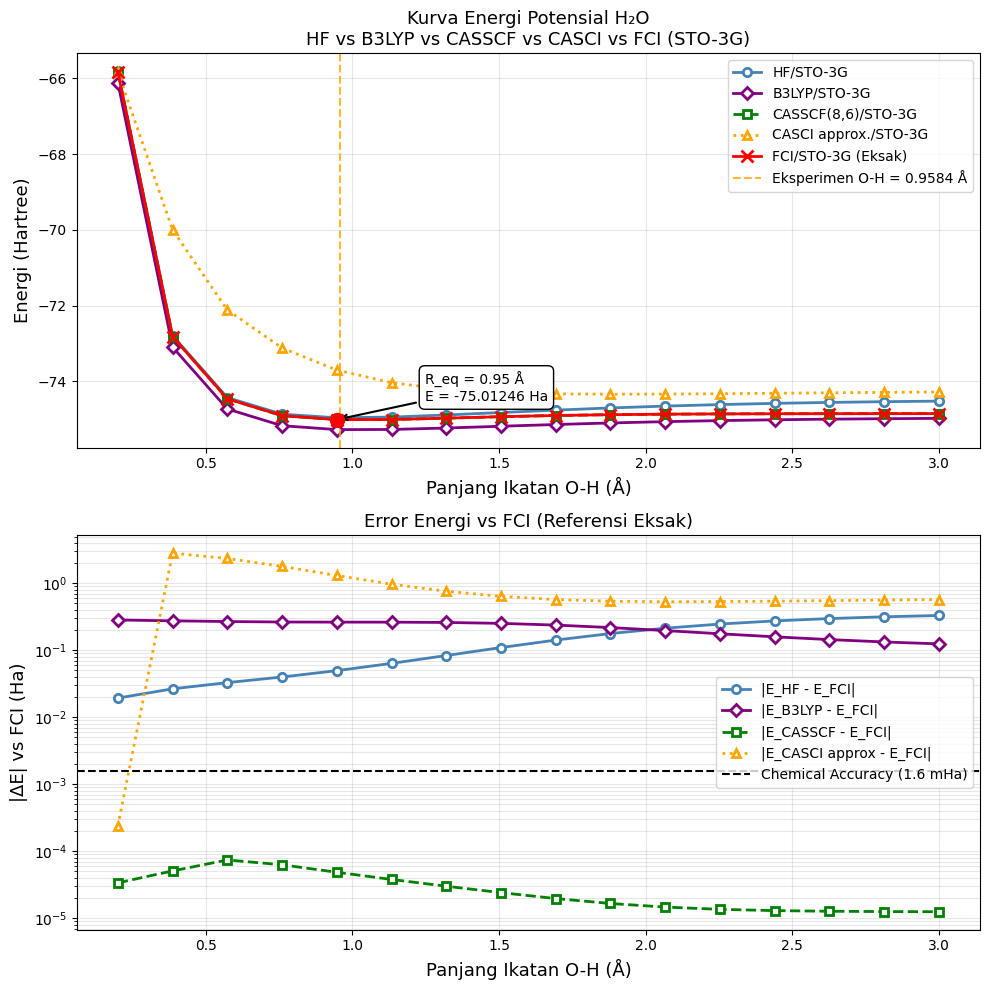

FCI    → R_eq = 0.95 Å | E = -75.012461 Ha
CASSCF → R_eq = 0.95 Å | E = -75.012412 Ha


In [1]:
import matplotlib.pyplot as plt
import numpy as np

jarak = np.linspace(0.20, 3.00, 16)

energi_hf = [
    -65.806845162825,
    -72.793449568902,
    -74.429527148394,
    -74.867934490072,
    -74.962807989850,
    -74.945135249045,
    -74.889658857364,
    -74.824727459055,
    -74.761075397650,
    -74.703573381169,
    -74.654598768980,
    -74.614580215022,
    -74.582696023498,
    -74.557659137104,
    -74.538167465075,
    -74.523045762054
]

energi_dft = [
    -66.109615314697,
    -73.095484497747,
    -74.731073268571,
    -75.172334132054,
    -75.275859662330,
    -75.271995212046,
    -75.233536405183,
    -75.186801225814,
    -75.140947715456,
    -75.099817871339,
    -75.065267957051,
    -75.037608187194,
    -75.016141978887,
    -74.999816233866,
    -74.987593191302,
    -74.978601609472
]

energi_casscf = [
    -65.826140591478,
    -72.819970177160,
    -74.462339455416,
    -74.907776452539,
    -75.012412447078,
    -75.008837892233,
    -74.973175372795,
    -74.934507373189,
    -74.903075172534,
    -74.881421356997,
    -74.868316593036,
    -74.861071670803,
    -74.857277433606,
    -74.855356607624,
    -74.854411040105,
    -74.853958321358
]

energi_casci = [
    -65.825936286341,
    -69.999460944079,
    -72.113676878574,
    -73.119122625715,
    -73.702446711864,
    -74.037582758271,
    -74.211757099609,
    -74.296102479847,
    -74.331583285483,
    -74.341060782799,
    -74.337379477468,
    -74.327676089556,
    -74.315764457715,
    -74.303572359020,
    -74.291995977966,
    -74.281384934961
]

energi_fci = [
    -65.826174251028,
    -72.820020949044,
    -74.462413405084,
    -74.907839102179,
    -75.012460920566,
    -75.008875736423,
    -74.973205354435,
    -74.934531424790,
    -74.903094801021,
    -74.881437913534,
    -74.868331220728,
    -74.861085213714,
    -74.857290396455,
    -74.855369283774,
    -74.854423580792,
    -74.853970800445
]

# Referensi = FCI
e_ref      = np.array(energi_fci)
error_hf   = np.abs(np.array(energi_hf)    - e_ref)
error_dft  = np.abs(np.array(energi_dft)   - e_ref)
error_casscf = np.abs(np.array(energi_casscf) - e_ref)
error_casci  = np.abs(np.array(energi_casci)  - e_ref)

CA = 0.0016

idx_fci    = energi_fci.index(min(energi_fci))
idx_casscf = energi_casscf.index(min(energi_casscf))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# ── Plot 1: PES ──
ax1.plot(jarak, energi_hf,    'o-',  color='steelblue', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(jarak, energi_dft,   'D-',  color='purple',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(jarak, energi_casscf,'s--', color='green',     linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(8,6)/STO-3G')
ax1.plot(jarak, energi_casci, '^:',  color='orange',    linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI approx./STO-3G')
ax1.plot(jarak, energi_fci,   'x-',  color='red',       linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI/STO-3G (Eksak)')

ax1.plot(jarak[idx_fci], energi_fci[idx_fci], 'ro', markersize=10, zorder=5)
ax1.annotate(f'R_eq = {jarak[idx_fci]:.2f} Å\nE = {energi_fci[idx_fci]:.5f} Ha',
             xy=(jarak[idx_fci], energi_fci[idx_fci]),
             xytext=(jarak[idx_fci]+0.3, energi_fci[idx_fci]+0.5),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='black', linewidth=1))

ax1.axvline(x=0.9584, color='orange', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Eksperimen O-H = 0.9584 Å')
ax1.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial H₂O\nHF vs B3LYP vs CASSCF vs CASCI vs FCI (STO-3G)',
              fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Error vs FCI ──
ax2.semilogy(jarak, error_hf     + 1e-10, 'o-',  color='steelblue', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF - E_FCI|')
ax2.semilogy(jarak, error_dft    + 1e-10, 'D-',  color='purple',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP - E_FCI|')
ax2.semilogy(jarak, error_casscf + 1e-10, 's--', color='green',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF - E_FCI|')
ax2.semilogy(jarak, error_casci  + 1e-10, '^:',  color='orange',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI approx - E_FCI|')
ax2.axhline(y=CA, color='black', linestyle='--',
            linewidth=1.5, label='Chemical Accuracy (1.6 mHa)')
ax2.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=13)
ax2.set_ylabel('|ΔE| vs FCI (Ha)', fontsize=13)
ax2.set_title('Error Energi vs FCI (Referensi Eksak)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('PES_H2O_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"FCI    → R_eq = {jarak[idx_fci]:.2f} Å | E = {energi_fci[idx_fci]:.6f} Ha")
print(f"CASSCF → R_eq = {jarak[idx_casscf]:.2f} Å | E = {energi_casscf[idx_casscf]:.6f} Ha")

In [2]:
# ═══════════════════════════════════════════════════════════
# RINGKASAN ENERGI ELEKTRONIK - H2O (STO-3G)
# ═══════════════════════════════════════════════════════════
print("="*65)
print("RINGKASAN ENERGI ELEKTRONIK MOLEKUL H₂O (STO-3G)")
print("="*65)
print(f"{'Metode':<20} {'E_min (Ha)':>15} {'R_eq (Å)':>12} {'ΔE vs FCI (Ha)':>16}")
print("-"*65)

metode_h2o = {
    'HF':              energi_hf,
    'B3LYP':           energi_dft,
    'CASSCF(8,6)':     energi_casscf,
    'CASCI approx.':   energi_casci,
}

e_fci_min = min(energi_fci)
idx_fci   = energi_fci.index(e_fci_min)

for nama, data in metode_h2o.items():
    idx   = data.index(min(data))
    e_min = data[idx]
    r_eq  = jarak[idx]
    delta = abs(e_min - e_fci_min)
    print(f"{nama:<20} {e_min:>15.6f} {r_eq:>12.2f} {delta:>16.6e}")

print("-"*65)
print(f"{'FCI (eksak)':<20} {e_fci_min:>15.6f} {jarak[idx_fci]:>12.2f} {'referensi':>16}")
print("="*65)

RINGKASAN ENERGI ELEKTRONIK MOLEKUL H₂O (STO-3G)
Metode                    E_min (Ha)     R_eq (Å)   ΔE vs FCI (Ha)
-----------------------------------------------------------------
HF                        -74.962808         0.95     4.965293e-02
B3LYP                     -75.275860         0.95     2.633987e-01
CASSCF(8,6)               -75.012412         0.95     4.847349e-05
CASCI approx.             -74.341061         1.88     6.714001e-01
-----------------------------------------------------------------
FCI (eksak)               -75.012461         0.95        referensi
